# NeighborsMatch Diagnostic — HybridGraphFNet
Tests long-range propagation capability at increasing problem radius r.
GCN/GIN collapse at r>=5. HybridGraphFNet should maintain high accuracy.

In [1]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import to_dense_batch, to_dense_adj
from tqdm import tqdm
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Cell 1 — Dataset Generator
Generates binary trees of depth r. Task: does the root have a neighbor matching its label?

In [3]:
def generate_neighbors_match(r, num_graphs=3000, seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    data_list  = []
    num_nodes  = 2**(r+1) - 1
    num_leaves = 2**r
    leaf_start = num_nodes - num_leaves

    edges_src, edges_dst = [], []
    for node in range(num_nodes):
        left  = 2 * node + 1
        right = 2 * node + 2
        if left < num_nodes:
            edges_src += [node, left]
            edges_dst += [left, node]
        if right < num_nodes:
            edges_src += [node, right]
            edges_dst += [right, node]

    edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

    for _ in range(num_graphs):
        root_val = random.randint(0, 1)
        label    = random.randint(0, 1)   # 0=left half, 1=right half
        half     = num_leaves // 2

        node_vals = [1 - root_val] * num_nodes
        node_vals[0] = root_val  # root has its value

        # Place matching leaf in correct half
        if label == 0:
            target = leaf_start + random.randint(0, half - 1)
        else:
            target = leaf_start + half + random.randint(0, half - 1)
        node_vals[target] = root_val

        # Features: [value, is_leaf] — NO is_root flag
        # Removing is_root forces the model to learn topology
        x = []
        for i, v in enumerate(node_vals):
            is_leaf = 1.0 if i >= leaf_start else 0.0
            x.append([float(v), is_leaf])
        x = torch.tensor(x, dtype=torch.float)
        y = torch.tensor([label], dtype=torch.long)

        data_list.append(Data(x=x, edge_index=edge_index.clone(), y=y))

    return data_list

## Cell 2 — Model Components (paste your full model here)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import to_dense_batch, to_dense_adj

class DenseGCNLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.node_lin = nn.Linear(hidden_dim, hidden_dim)
        self.norm     = nn.LayerNorm(hidden_dim)

    def forward(self, x, A_norm):
        msg = torch.bmm(A_norm, x)
        return self.norm(F.gelu(self.node_lin(msg)))

class SpectralMixMH(nn.Module):
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.filter_gen = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj   = nn.Linear(hidden_dim, hidden_dim)
        self.norm       = nn.LayerNorm(hidden_dim)

    def forward(self, x, U, mask):
        # 1. Project to spectral domain
        x_hat      = torch.bmm(U.transpose(1, 2), x)

        # 2. Apply learned global filter
        fil        = torch.sigmoid(self.filter_gen(x_hat))
        x_filtered = fil * x_hat

        # 3. Project back to spatial domain
        x_out      = torch.bmm(U, x_filtered)
        x_out      = x_out * mask.unsqueeze(-1)

        # --- FIX 2: INJECT LOCAL IDENTITY (RESIDUAL) ---
        # Ensures the identity feature survives the frequency domain trip
        # which helps with the "needle in a haystack" routing problem
        return self.norm(self.out_proj(F.gelu(x_out)) + x)

class HybridGraphFNet_NM(nn.Module):
    """
    HybridGraphFNet for NeighborsMatch.
    Node-level prediction at root node (index 0).
    Forces genuine long-range propagation from leaves to root.
    """
    def __init__(
        self,
        in_dim,
        hidden_dim = 128,
        num_layers = 4,
        out_dim    = 2,
        num_heads  = 4,
        lap_k      = 8,
        dropout    = 0.1,
    ):
        super().__init__()
        self.lap_k   = lap_k
        self.dropout = nn.Dropout(dropout)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.pe_encoder = nn.Linear(lap_k, hidden_dim)

        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'local':  DenseGCNLayer(hidden_dim),
                'global': SpectralMixMH(hidden_dim, num_heads),
                'gate':   nn.Linear(hidden_dim, hidden_dim),
                'norm':   nn.LayerNorm(hidden_dim),
            })
            for _ in range(num_layers)
        ])

        # Node-level classifier — predict at root node only
        self.node_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )

    def compute_laplacian_basis(self, adj, mask):
        B, N, _ = adj.shape
        A_list, U_list = [], []

        for b in range(B):
            n      = int(mask[b].sum().item())
            adj_b  = adj[b, :n, :n]
            deg    = adj_b.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
            D_inv_sqrt   = torch.diag(deg_inv_sqrt)
            A_norm_b     = D_inv_sqrt @ adj_b @ D_inv_sqrt


            L_b = torch.eye(n, device=adj.device) - A_norm_b

            try:
                _, U_b = torch.linalg.eigh(L_b)
                # Sign canonicalization
                max_abs_idx = torch.abs(U_b).argmax(dim=0)
                signs = torch.sign(
                    U_b[max_abs_idx, torch.arange(U_b.size(1), device=adj.device)]
                )
                signs[signs == 0] = 1.0
                U_b = U_b * signs.unsqueeze(0)
            except Exception:
                U_b = torch.eye(n, device=adj.device)

            A_pad = F.pad(A_norm_b, (0, N-n, 0, N-n))
            U_pad = F.pad(U_b,      (0, N-n, 0, N-n))
            A_list.append(A_pad)
            U_list.append(U_pad)

        return torch.stack(A_list), torch.stack(U_list)

    def forward(self, data):
        x, mask = to_dense_batch(data.x.float(), data.batch)
        adj     = to_dense_adj(data.edge_index, data.batch,
                               max_num_nodes=x.size(1))
        I   = torch.eye(adj.size(1), device=x.device).unsqueeze(0)
        adj = adj + I

        A_norm, U = self.compute_laplacian_basis(adj, mask)

        x = self.input_proj(x)

        k      = min(self.lap_k, U.size(-1))
        lap_pe = U[:, :, :k] * mask.unsqueeze(-1)
        if k < self.lap_k:
            lap_pe = F.pad(lap_pe, (0, self.lap_k - k))
        x = x + self.pe_encoder(lap_pe)

        for layer in self.layers:
            x_res    = x
            x_local  = layer['local'](x, A_norm)
            x_global = layer['global'](x, U, mask)

            # Per-node, per-feature gating
            gate     = torch.sigmoid(layer['gate'](x))
            x_mix    = gate * x_local + (1 - gate) * x_global

            x        = layer['norm'](x_res + self.dropout(x_mix))

        # Extract root node representation (always index 0)
        root_repr = x[:, 0, :]               # [B, H]
        return self.node_classifier(root_repr)


class GCN_NM(nn.Module):
    """
    GCN baseline for NeighborsMatch.
    Same node-level prediction at root — fair comparison.
    """
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, out_dim=2):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.convs = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])
        self.node_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, data):
        x, mask = to_dense_batch(data.x.float(), data.batch)
        adj     = to_dense_adj(data.edge_index, data.batch,
                               max_num_nodes=x.size(1))
        I       = torch.eye(adj.size(1), device=x.device).unsqueeze(0)
        adj     = adj + I

        deg          = adj.sum(dim=2)
        deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
        D_inv_sqrt   = torch.diag_embed(deg_inv_sqrt)
        A_norm       = torch.bmm(torch.bmm(D_inv_sqrt, adj), D_inv_sqrt)

        x = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            x = norm(F.gelu(conv(torch.bmm(A_norm, x))) + x)

        # Extract root node representation (always index 0)
        root_repr = x[:, 0, :]
        return self.node_classifier(root_repr)


print('Models defined.')
print('HybridGraphFNet_NM — root node prediction, no pooling')
print('GCN_NM            — root node prediction, no pooling')

Models defined.
HybridGraphFNet_NM — root node prediction, no pooling
GCN_NM            — root node prediction, no pooling


## Cell 3 — Training Function

In [9]:
def train_nm(model, train_loader, val_loader, epochs=200, lr=1e-3, patience=30):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss()

    best_val_acc      = 0.0
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = criterion(out, batch.y.squeeze())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(dim=1) == batch.y.squeeze()).sum().item()
            total      += batch.y.size(0)

        scheduler.step()
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out   = model(batch)
                val_correct += (out.argmax(dim=1) == batch.y.squeeze()).sum().item()
                val_total   += batch.y.size(0)
        val_acc = val_correct / val_total

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:03d} | Loss {total_loss/len(train_loader):.4f} | '
                  f'Train {train_acc:.4f} | Val {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc      = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    return best_val_acc

print('Training function defined.')

Training function defined.


## Cell 4 — Run Experiment Across Radii

In [15]:
RADII       = [2, 3, 4, 5]
HIDDEN_DIM  = 128   # bigger
NUM_LAYERS  = 4
BATCH_SIZE  = 64
EPOCHS      = 500
PATIENCE    = 50
NUM_GRAPHS  = 3000  # more data

results_hybrid = {}
results_gcn    = {}

for r in RADII:
    num_nodes = 2**(r+1) - 1
    print(f'\n{"="*50}')
    print(f'r={r} | nodes={num_nodes} | task=binary (left/right)')
    print(f'{"="*50}')

    all_data  = generate_neighbors_match(r, num_graphs=NUM_GRAPHS)
    split     = int(0.8 * len(all_data))
    train_loader = DataLoader(all_data[:split],  batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(all_data[split:],  batch_size=BATCH_SIZE)

    # HybridGraphFNet — out_dim=2 always
    model_hybrid = HybridGraphFNet_NM(
        in_dim     = 2,
        hidden_dim = 128,
        num_layers = NUM_LAYERS,
        out_dim    = 2,
        lap_k      = min(8, num_nodes - 1)
    ).to(device)

    # GCN — hidden_dim = 256 (~265k params)
    model_gcn = GCN_NM(
        in_dim     = 2,
        hidden_dim = 256,  # Scaled up for fair baseline comparison
        num_layers = NUM_LAYERS,
        out_dim    = 2
    ).to(device)
    print(f'HybridGraphFNet | params={sum(p.numel() for p in model_hybrid.parameters()):,}')
    acc_h = train_nm(model_hybrid, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE)
    results_hybrid[r] = acc_h
    print(f'  Best Val: {acc_h:.4f}')
    print(f'GCN | params={sum(p.numel() for p in model_gcn.parameters()):,}')
    acc_g = train_nm(model_gcn, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE)
    results_gcn[r] = acc_g
    print(f'  Best Val: {acc_g:.4f}')


r=2 | nodes=7 | task=binary (left/right)
HybridGraphFNet | params=285,314


/tmp/ipykernel_1328/1139458107.py:20: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(all_data[:split],  batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_1328/1139458107.py:21: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(all_data[split:],  batch_size=BATCH_SIZE)


  Epoch 020 | Loss 0.0001 | Train 1.0000 | Val 1.0000
  Epoch 040 | Loss 0.0000 | Train 1.0000 | Val 1.0000
  Early stopping at epoch 57
  Best Val: 1.0000
GCN | params=332,290
  Epoch 020 | Loss 0.6936 | Train 0.4929 | Val 0.5133
  Epoch 040 | Loss 0.6931 | Train 0.5067 | Val 0.5133
  Early stopping at epoch 52
  Best Val: 0.5267

r=3 | nodes=15 | task=binary (left/right)
HybridGraphFNet | params=285,570
  Epoch 020 | Loss 0.6930 | Train 0.5012 | Val 0.5133
  Epoch 040 | Loss 0.6937 | Train 0.4963 | Val 0.4733
  Epoch 060 | Loss 0.0001 | Train 1.0000 | Val 1.0000
  Epoch 080 | Loss 0.0000 | Train 1.0000 | Val 1.0000
  Epoch 100 | Loss 0.0000 | Train 1.0000 | Val 1.0000
  Early stopping at epoch 100
  Best Val: 1.0000
GCN | params=332,290
  Epoch 020 | Loss 0.6935 | Train 0.4917 | Val 0.5133
  Epoch 040 | Loss 0.6933 | Train 0.5054 | Val 0.5133
  Early stopping at epoch 52
  Best Val: 0.5133

r=4 | nodes=31 | task=binary (left/right)
HybridGraphFNet | params=285,570
  Epoch 020 | Loss 

## Cell 5 — Plot Results

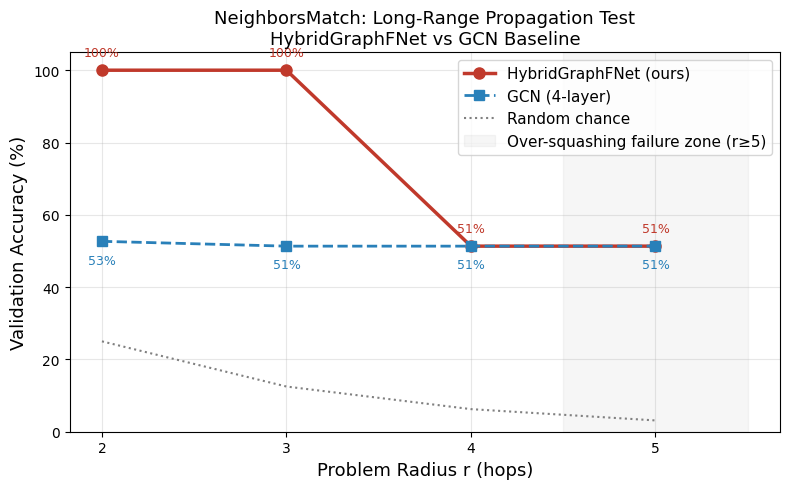

Saved to neighbors_match_results.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

radii   = sorted(results_hybrid.keys())
hybrid  = [results_hybrid[r] * 100 for r in radii]
gcn     = [results_gcn[r]    * 100 for r in radii]
chance  = [100 / (2**r) for r in radii]  # random chance per radius

ax.plot(radii, hybrid,  'o-', color='#c0392b', linewidth=2.5,
        markersize=8, label='HybridGraphFNet (ours)', zorder=3)
ax.plot(radii, gcn,     's--', color='#2980b9', linewidth=2,
        markersize=7, label='GCN (4-layer)', zorder=3)
ax.plot(radii, chance,  ':',  color='gray', linewidth=1.5,
        label='Random chance', zorder=2)

# Shade the over-squashing failure zone
ax.axvspan(4.5, max(radii) + 0.5, alpha=0.07, color='gray',
           label='Over-squashing failure zone (r≥5)')

ax.set_xlabel('Problem Radius r (hops)', fontsize=13)
ax.set_ylabel('Validation Accuracy (%)', fontsize=13)
ax.set_title('NeighborsMatch: Long-Range Propagation Test\n'
             'HybridGraphFNet vs GCN Baseline', fontsize=13)
ax.set_xticks(radii)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate key points
for r, h, g in zip(radii, hybrid, gcn):
    ax.annotate(f'{h:.0f}%', (r, h), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, color='#c0392b')
    ax.annotate(f'{g:.0f}%', (r, g), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=9, color='#2980b9')

plt.tight_layout()
plt.savefig('neighbors_match_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to neighbors_match_results.png')

## Cell 6 — Log Results

In [17]:
import csv, os

filepath   = 'neighbors_match_results.csv'
fieldnames = ['radius', 'num_nodes', 'num_leaves', 'model', 'val_acc']

rows = []
for r in RADII:
    rows.append({
        'radius': r, 'num_nodes': 2**(r+1)-1,
        'num_leaves': 2**r, 'model': 'HybridGraphFNet',
        'val_acc': results_hybrid[r]
    })
    rows.append({
        'radius': r, 'num_nodes': 2**(r+1)-1,
        'num_leaves': 2**r, 'model': 'GCN',
        'val_acc': results_gcn[r]
    })

with open(filepath, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f'Results saved to {filepath}')
print(f'\nFinal Table:')
print(f'{"r":>4}  {"nodes":>7}  {"HybridGFNet":>12}  {"GCN":>8}  {"Chance":>8}')
print('-' * 48)
for r in RADII:
    nodes  = 2**(r+1) - 1
    chance = 100 / (2**r)
    print(f'{r:>4}  {nodes:>7}  '
          f'{results_hybrid[r]*100:>11.1f}%  '
          f'{results_gcn[r]*100:>7.1f}%  '
          f'{chance:>7.1f}%')

Results saved to neighbors_match_results.csv

Final Table:
   r    nodes   HybridGFNet       GCN    Chance
------------------------------------------------
   2        7        100.0%     52.7%     25.0%
   3       15        100.0%     51.3%     12.5%
   4       31         51.3%     51.3%      6.2%
   5       63         51.3%     51.3%      3.1%
